In [2]:
import os
import xml.etree.ElementTree as ET
import cv2
import pandas as pd
import matplotlib.pyplot as plt

ANN_DIR = "../data/annotations"
IMG_DIR = "../data/images"

print(len(os.listdir(ANN_DIR)), "annotation files")
print(len(os.listdir(IMG_DIR)), "images")

848 annotation files
784 images


In [4]:
with open(os.path.join(ANN_DIR, "maksssksksss2.xml")) as f:
    print(f.read())


<annotation>
    <folder>images</folder>
    <filename>maksssksksss2.png</filename>
    <size>
        <width>400</width>
        <height>290</height>
        <depth>3</depth>
    </size>
    <segmented>0</segmented>
    <object>
        <name>with_mask</name>
        <pose>Unspecified</pose>
        <truncated>0</truncated>
        <occluded>0</occluded>
        <difficult>0</difficult>
        <bndbox>
            <xmin>68</xmin>
            <ymin>42</ymin>
            <xmax>105</xmax>
            <ymax>69</ymax>
        </bndbox>
    </object>
    <object>
        <name>with_mask</name>
        <pose>Unspecified</pose>
        <truncated>0</truncated>
        <occluded>0</occluded>
        <difficult>0</difficult>
        <bndbox>
            <xmin>154</xmin>
            <ymin>47</ymin>
            <xmax>178</xmax>
            <ymax>74</ymax>
        </bndbox>
    </object>
    <object>
        <name>with_mask</name>
        <pose>Unspecified</pose>
        <truncated>0</truncated>

In [7]:
def parse_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    filename = root.find("filename").text
    boxes = []
    for obj in root.findall("object"):
        label = obj.find("name").text
        bb = obj.find("bndbox")
        xmin = int(bb.find("xmin").text)
        ymin = int(bb.find("ymin").text)
        xmax = int(bb.find("xmax").text)
        ymax = int(bb.find("ymax").text)
        boxes.append((label, xmin, ymin, xmax, ymax))
    return filename, boxes

parse_xml(os.path.join(ANN_DIR, "maksssksksss2.xml"))

('maksssksksss2.png',
 [('with_mask', 68, 42, 105, 69),
  ('with_mask', 154, 47, 178, 74),
  ('with_mask', 238, 34, 262, 69),
  ('mask_weared_incorrect', 333, 31, 366, 65)])

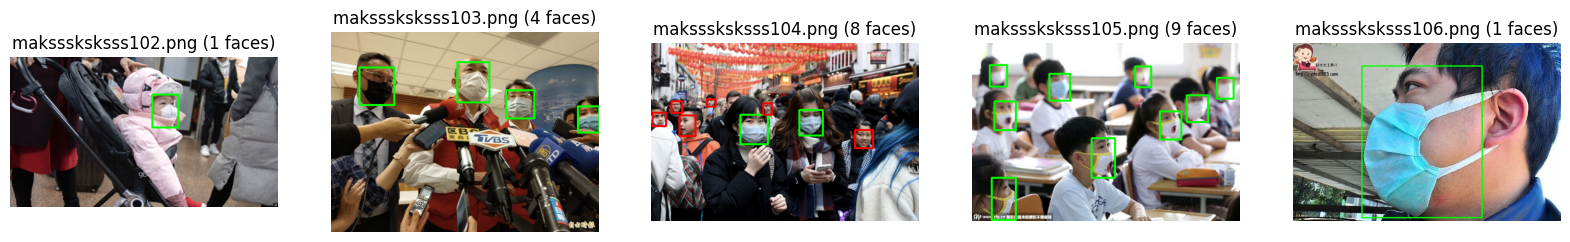

In [8]:
COLORS = {
    "with_mask": (0, 255, 0),            # green
    "without_mask": (0, 0, 255),         # red
    "mask_weared_incorrect": (0, 165, 255)  # orange
}

xml_files = sorted(os.listdir(ANN_DIR))[:5]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, xml_file in zip(axes, xml_files):
    filename, boxes = parse_xml(os.path.join(ANN_DIR, xml_file))
    img = cv2.imread(os.path.join(IMG_DIR, filename))
    for label, x1, y1, x2, y2 in boxes:
        cv2.rectangle(img, (x1, y1), (x2, y2), COLORS[label], 2)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"{filename} ({len(boxes)} faces)")
    ax.axis("off")
plt.show()

In [9]:
rows = []
for xml_file in os.listdir(ANN_DIR):
    filename, boxes = parse_xml(os.path.join(ANN_DIR, xml_file))
    for label, x1, y1, x2, y2 in boxes:
        rows.append({
            "filename": filename,
            "class": label,
            "width": x2 - x1,
            "height": y2 - y1,
            "area": (x2 - x1) * (y2 - y1)
        })

df = pd.DataFrame(rows)
print(df.shape)
df.head()

(4055, 5)


,filename,class,width,height,area
0,maksssksksss102.png,with_mask,39,49,1911
1,maksssksksss103.png,with_mask,52,56,2912
2,maksssksksss103.png,with_mask,48,60,2880
3,maksssksksss103.png,with_mask,42,42,1764
4,maksssksksss103.png,with_mask,32,39,1248


class
with_mask                3218
without_mask              714
mask_weared_incorrect     123
Name: count, dtype: int64
class
with_mask                79.4
without_mask             17.6
mask_weared_incorrect     3.0
Name: count, dtype: float64


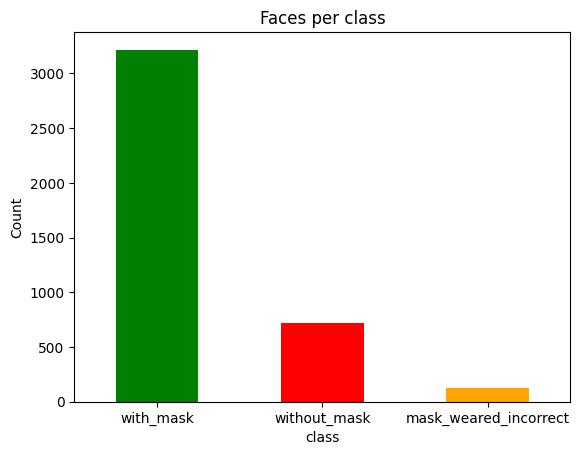

In [10]:
counts = df["class"].value_counts()
print(counts)
print((counts / counts.sum() * 100).round(1))

counts.plot(kind="bar", color=["green", "red", "orange"])
plt.title("Faces per class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

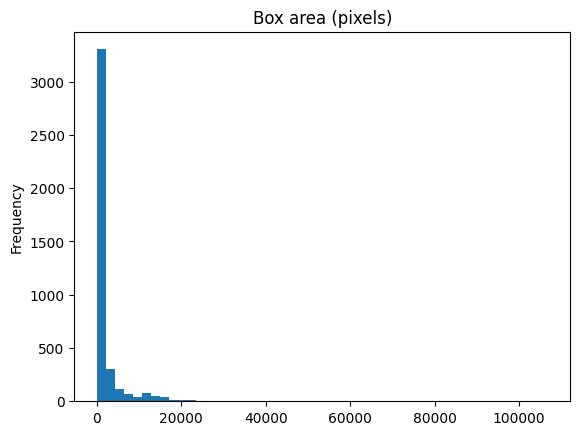

                       width  height
class                               
mask_weared_incorrect   27.0    31.0
with_mask               23.0    24.0
without_mask            18.0    20.0
Faces per image: count    848.000000
mean       4.781840
std        7.411711
min        1.000000
25%        1.000000
50%        2.000000
75%        6.000000
max      115.000000
dtype: float64


In [11]:
df["area"].plot(kind="hist", bins=50)
plt.title("Box area (pixels)")
plt.show()

print(df.groupby("class")[["width", "height"]].median())
print("Faces per image:", df.groupby("filename").size().describe())

## Findings
- Class split: with_mask 79.4%, without_mask 17.6%, mask_weared_incorrect 3.0%
  (about 26:1). Strong imbalance, so I'll track per-class recall, not accuracy.
- Faces are small: median box 18-31 px. without_mask is the smallest (18x20 px),
  which makes it harder to detect. I'll train at imgsz=640 to keep detail.
- Faces per image: median 2, mean 4.8, max 115. A few crowded images skew the
  distribution.
- 853 annotation files but 848 images in the DataFrame: [your finding from the check].